for tree visualization, install Graphviz in the with the following command:

Linux:
sudo apt-get install graphviz graphviz-dev libgraphviz-dev pkg-config

MacOS:
brew install graphviz

In [9]:
from cardroom.briscola.game.env import BriscolaEnv
from cardroom.briscola.game.player import BriscolaPlayer
from cardroom.briscola.agents.random import RandomAgent
from cardroom.briscola.agents.human import HumanAgent
from cardroom.briscola.agents.donatello import DonatelloAgent

In [10]:
def recap(root, depth=0):
    indent = "  " * depth
    print(f"{indent}Node: visits={root.visits}, W/D/L=({root.wins}/{root.draws}/{root.losses}), parent_action={root.parent_action}")
    for child in root.children:
        recap(child, depth + 1)

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

def plot_tree(root):
    G = nx.DiGraph()

    def add_nodes_edges(node):
        win_pct = 100 * node.wins / node.visits if node.visits > 0 else 0
        label = (f"A: {node.parent_action}\n"
                 f"V: {node.visits}\n"
                 f"W%: {win_pct:.1f}")
        G.add_node(id(node), label=label)
        for child in node.children:
            G.add_edge(id(node), id(child))
            add_nodes_edges(child)
    
    add_nodes_edges(root)

    pos = graphviz_layout(G, prog='dot')
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(3,2))
    nx.draw(G, pos,
            labels=labels,
            with_labels=True,
            arrows=True,
            node_size=3000,
            node_color='lightyellow',
            font_size=10,
            font_weight='bold',
            font_family='monospace',
            edge_color='gray',
            linewidths=1,
            connectionstyle='arc3,rad=0.1',
            alpha=0.9)

    plt.title("MCTS Tree Exploration (Improved Readability)", fontsize=14)
    plt.axis('off')
    plt.show()


In [12]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_tree_head(root):
    G = nx.DiGraph()

    # Root node
    root_win_pct = 100 * root.wins / root.visits if root.visits > 0 else 0
    root_label = (f"ROOT\n"
                  f"V: {root.visits}\n"
                  f"W%: {root_win_pct:.1f}")
    G.add_node("root", label=root_label)

    # Aggregate children by parent_action
    action_stats: dict[int, dict[str, float]] = {}
    for child in root.children:
        a = child.parent_action
        if a not in action_stats:
            action_stats[a] = {
                "wins": child.wins,
                "visits": child.visits,
            }
        else:
            action_stats[a]["wins"]   += child.wins
            action_stats[a]["visits"] += child.visits

    # Add aggregated action nodes
    for action, stats in sorted(action_stats.items()):
        win_pct = 100 * stats["wins"] / stats["visits"] if stats["visits"] > 0 else 0
        label = (f"A: {action}\n"
                 f"V: {stats['visits']}\n"
                 f"W%: {win_pct:.1f}")
        node_name = f"action_{action}"
        G.add_node(node_name, label=label)
        G.add_edge("root", node_name)

    # Layout without pygraphviz
    pos = nx.spring_layout(G, seed=42)  # or nx.kamada_kawai_layout(G)
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(3, 2))
    nx.draw(G, pos,
            labels=labels,
            with_labels=True,
            arrows=True,
            node_size=3000,
            node_color='lightyellow',
            font_size=10,
            font_weight='bold',
            font_family='monospace',
            edge_color='gray',
            linewidths=1,
            connectionstyle='arc3,rad=0.1',
            alpha=0.9)

    plt.title("MCTS First-Layer Aggregated Actions", fontsize=14)
    plt.axis('off')
    plt.show()


In [13]:
def plot_action_stats(root):
    actions = list(set([child.parent_action for child in root.children]))
    visits = [0] * len(actions)
    for child in root.children:
        visits[child.parent_action] += child.visits
    plt.bar(actions, visits)
    plt.xlabel("Action")
    plt.ylabel("Visits")
    plt.title("MCTS Action Visit Counts")
    plt.show()


In [ ]:
def write_action_stats(root):
    # Print root stats
    root_win_pct = 100 * root.wins / root.visits if root.visits > 0 else 0
    print(f"ROOT: V: {root.visits}, W%: {root_win_pct:.1f}")

    # Aggregate children by action
    action_stats: dict[int, dict[str, float]] = {}
    for child in root.children:
        a = child.parent_action
        if a not in action_stats:
            action_stats[a] = {
                "wins": child.wins,
                "visits": child.visits,
            }
        else:
            action_stats[a]["wins"]   += child.wins
            action_stats[a]["visits"] += child.visits

    # Print stats for each action
    for action, stats in sorted(action_stats.items()):
        win_pct = 100 * stats["wins"] / stats["visits"] if stats["visits"] > 0 else 0
        print(f"Action {action}: V: {stats['visits']}, W%: {win_pct:.1f}")


In [14]:
SIMULATIONS = 100

render_mode = "text"

human = HumanAgent(input_mode=render_mode)
random = RandomAgent()
donatello = DonatelloAgent(simulations = SIMULATIONS)
names = ["Donatello", "Random"]

env = BriscolaEnv(names, render_mode=render_mode)
if render_mode == "pygame":
    human.set_pygame_action_retriever(env.pygame)
agents = [donatello, random]

New game starting!
Players: ['Donatello', 'Random']
Donatello to start.
Briscola: Coppe - Spy: J of Coppe


['3 of Coppe', '5 of Ori', '7 of Ori']


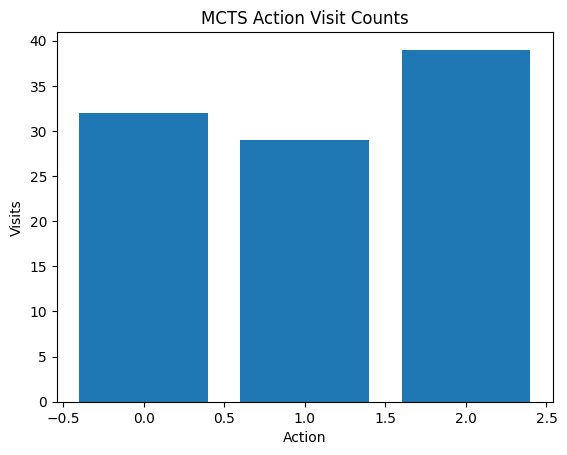

In [15]:
while not env.done:
    player_id = env.current_player_id
    player = env.players[player_id]
    agent = agents[player_id]
    if isinstance(agent, DonatelloAgent): # ugly. should be the same call for all agents
        action, root = agent.select_action(env.get_observation(), env.clone_from_observation(), return_root=True)
        print([env.get_observation()["hand"][i].__str__() for i in range(len(env.get_observation()["hand"]))])
        # recap(root)
        plot_action_stats(root)
        #plot_tree_head(root)

        if input("Press enter to continue, q to quit: ") == "q":
            break
    else:
        action = agent.select_action(env.get_observation())
    env.step(action)